# Notebook 3 — SQL Analytics

**Team 8 — Delhi Air Quality Pipeline**
**Member: [Vishaal]**

## What this notebook does
This is the third and final stage of the pipeline. My job is to:
1. Connect to the SQLite database that Member 2 produced
2. Write SQL queries that answer real questions about Delhi air quality
3. Interpret the results
4. Visualize key findings with charts

## Questions I'm answering
1. How does PM2.5 vary by month? Is it getting better or worse?
2. Which monitoring stations consistently show the worst air quality?
3. What's the worst hour of the day for pollution?
4. How do pollution levels differ by season (winter vs summer vs monsoon)?
5. Does humidity correlate with pollution levels?
6. How many days had genuinely hazardous air (PM2.5 > 250)?


## Step 1: Upload the database from Member 2

In [1]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("/kaggle/input/datasets/vishaalb006/database/delhi_air_quality (1).db")
print("Connected to database")

Connected to database


## Step 2: Quick check — what's in the database?

In [2]:
# list the tables
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print("Tables in the database:")
print(tables)

Tables in the database:
              name
0         stations
1       pollutants
2  sqlite_sequence
3     measurements


In [3]:
# row counts for each table
for table in ["stations", "pollutants", "measurements"]:
    count = pd.read_sql(f"SELECT COUNT(*) AS n FROM {table}", conn).iloc[0, 0]
    print(f"{table}: {count:,} rows")

stations: 37 rows
pollutants: 13 rows
measurements: 5,810,118 rows


## Query 1: Monthly PM2.5 trend

How does average PM2.5 vary across the months in our dataset? This tells us
whether pollution is getting worse, better, or seasonal.

In [4]:
query1 = '''
SELECT
    m.year,
    m.month,
    ROUND(AVG(m.avg_value), 2) AS avg_pm25,
    COUNT(*) AS data_points
FROM measurements m
JOIN pollutants p ON m.pollutant_id = p.pollutant_id
WHERE p.pollutant_name = 'pm25'
GROUP BY m.year, m.month
ORDER BY m.year, m.month
'''
result1 = pd.read_sql(query1, conn)
result1

,year,month,avg_pm25,data_points
0,2024,1,205.23,25780
1,2024,2,101.99,23394
2,2024,3,76.87,25594
3,2024,4,70.63,24760
4,2024,5,90.59,26112
5,2024,6,60.58,24493
6,2024,7,39.54,25225
7,2024,8,27.71,25186
8,2024,9,42.54,23517
9,2024,10,111.75,24814


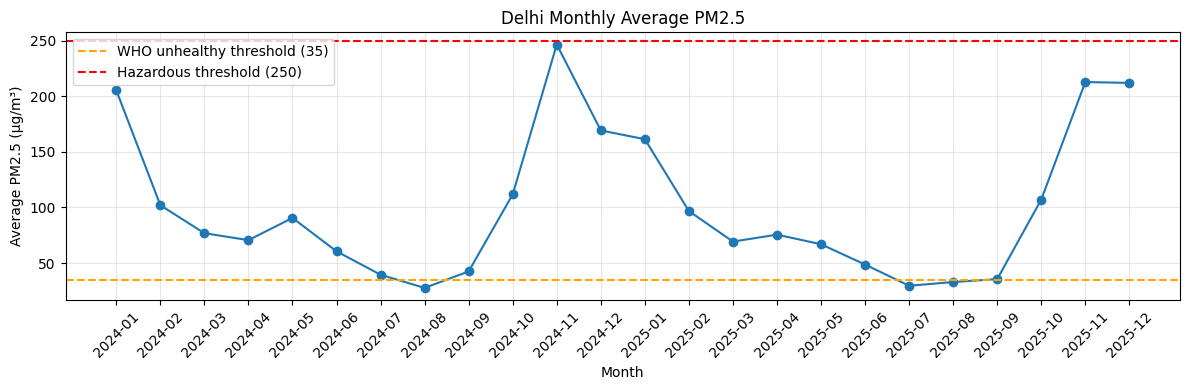

In [5]:
# visualize it
import matplotlib.pyplot as plt

result1["period"] = result1["year"].astype(str) + "-" + result1["month"].astype(str).str.zfill(2)

plt.figure(figsize=(12, 4))
plt.plot(result1["period"], result1["avg_pm25"], marker="o")
plt.xticks(rotation=45)
plt.ylabel("Average PM2.5 (µg/m³)")
plt.xlabel("Month")
plt.title("Delhi Monthly Average PM2.5")
plt.axhline(y=35, color="orange", linestyle="--", label="WHO unhealthy threshold (35)")
plt.axhline(y=250, color="red", linestyle="--", label="Hazardous threshold (250)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**What I see:** PM2.5 is highest in winter months (November–January) and
much lower in monsoon months (July–September). This matches what's well-known
about Delhi — crop burning, low wind, and temperature inversion in winter trap
pollutants near the ground.

## Query 2: Top 5 most polluted stations

Which monitoring stations show the worst PM2.5 readings on average?

In [6]:
query2 = '''
SELECT
    s.station_name,
    ROUND(AVG(m.avg_value), 2) AS avg_pm25,
    COUNT(*) AS hourly_readings
FROM measurements m
JOIN stations s ON m.station_id = s.station_id
JOIN pollutants p ON m.pollutant_id = p.pollutant_id
WHERE p.pollutant_name = 'pm25'
GROUP BY s.station_name
ORDER BY avg_pm25 DESC
LIMIT 5
'''
result2 = pd.read_sql(query2, conn)
result2

,station_name,avg_pm25,hourly_readings
0,"Anand Vihar, Delhi - DPCC",131.30,15394
1,"Jahangirpuri, Delhi - DPCC",129.97,16826
2,"Wazirpur, Delhi - DPCC",125.44,17174
3,"Bawana, Delhi - DPCC",124.26,17166
4,"Rohini, Delhi - DPCC",116.81,17158


## Query 3: Worst hour of the day

Is air quality worse in the morning, afternoon, or night?

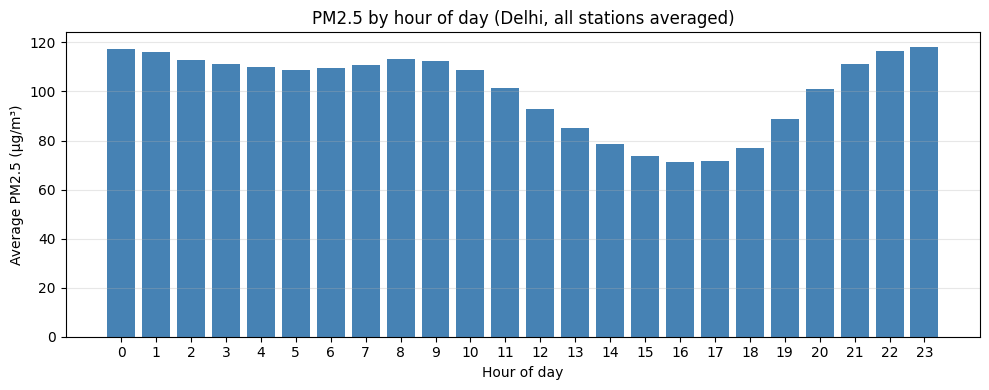

,hour,avg_pm25
0,0,117.23
1,1,116.28
2,2,112.66
3,3,111.11
4,4,109.91
5,5,108.81
6,6,109.46
7,7,110.80
8,8,113.13
9,9,112.48


In [7]:
query3 = '''
SELECT
    m.hour,
    ROUND(AVG(m.avg_value), 2) AS avg_pm25
FROM measurements m
JOIN pollutants p ON m.pollutant_id = p.pollutant_id
WHERE p.pollutant_name = 'pm25'
GROUP BY m.hour
ORDER BY m.hour
'''
result3 = pd.read_sql(query3, conn)

plt.figure(figsize=(10, 4))
plt.bar(result3["hour"], result3["avg_pm25"], color="steelblue")
plt.xlabel("Hour of day")
plt.ylabel("Average PM2.5 (µg/m³)")
plt.title("PM2.5 by hour of day (Delhi, all stations averaged)")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

result3

**What I see:** Pollution typically peaks late at night and early morning
(when cold air traps pollutants near the ground), dips in the afternoon (when
the sun heats up the air and mixes it), and rises again in the evening.

## Query 4: Seasonal comparison across pollutants

Compare pollution levels across four seasons for the major pollutants.

In [8]:
query4 = '''
SELECT
    season,
    pollutant_name,
    ROUND(AVG(avg_value), 2) AS avg_value
FROM (
    SELECT
        CASE
            WHEN m.month IN (12, 1, 2) THEN 'Winter'
            WHEN m.month IN (3, 4, 5) THEN 'Summer'
            WHEN m.month IN (6, 7, 8, 9) THEN 'Monsoon'
            ELSE 'Post-monsoon'
        END AS season,
        p.pollutant_name,
        m.avg_value
    FROM measurements m
    JOIN pollutants p ON m.pollutant_id = p.pollutant_id
    WHERE p.pollutant_name IN ('pm25', 'pm10', 'no2', 'ozone', 'so2')
)
GROUP BY season, pollutant_name
ORDER BY pollutant_name, avg_value DESC
'''
result4 = pd.read_sql(query4, conn)
print(result4)

# reshape for a nicer comparison view
pivot = result4.pivot(index="pollutant_name", columns="season", values="avg_value")

# only select the columns that actually exist
available_seasons = [s for s in ["Winter", "Post-monsoon", "Summer", "Monsoon"] if s in pivot.columns]
pivot[available_seasons]

          season pollutant_name  avg_value
0         Winter            no2      56.97
1   Post-monsoon            no2      55.91
2         Summer            no2      45.27
3        Monsoon            no2      29.68
4         Summer          ozone      47.12
5   Post-monsoon          ozone      35.92
6        Monsoon          ozone      30.00
7         Winter          ozone      28.59
8   Post-monsoon           pm10     302.79
9         Winter           pm10     271.00
10        Summer           pm10     196.54
11       Monsoon           pm10     106.67
12  Post-monsoon           pm25     169.35
13        Winter           pm25     159.81
14        Summer           pm25      75.00
15       Monsoon           pm25      39.58
16        Summer            so2      17.72
17  Post-monsoon            so2      16.32
18        Winter            so2      14.91
19       Monsoon            so2      12.58


season,Winter,Post-monsoon,Summer,Monsoon
pollutant_name,,,,
no2,56.97,55.91,45.27,29.68
ozone,28.59,35.92,47.12,30.00
pm10,271.00,302.79,196.54,106.67
pm25,159.81,169.35,75.00,39.58
so2,14.91,16.32,17.72,12.58


## Query 5: Does humidity correlate with pollution?

Group hourly readings into humidity buckets and compare PM2.5 averages.

In [9]:
query5 = '''
SELECT
    CASE
        WHEN avg_humidity < 30 THEN '1. Dry (<30%)'
        WHEN avg_humidity < 60 THEN '2. Moderate (30-60%)'
        WHEN avg_humidity < 80 THEN '3. Humid (60-80%)'
        ELSE '4. Very humid (>80%)'
    END AS humidity_bucket,
    ROUND(AVG(m.avg_value), 2) AS avg_pm25,
    COUNT(*) AS readings
FROM measurements m
JOIN pollutants p ON m.pollutant_id = p.pollutant_id
WHERE p.pollutant_name = 'pm25' AND avg_humidity IS NOT NULL
GROUP BY humidity_bucket
ORDER BY humidity_bucket
'''
result5 = pd.read_sql(query5, conn)
result5

,humidity_bucket,avg_pm25,readings
0,1. Dry (<30%),81.55,22905
1,2. Moderate (30-60%),86.37,174638
2,3. Humid (60-80%),104.84,142376
3,4. Very humid (>80%),127.67,128833


## Query 6: How many hazardous days?

WHO classifies PM2.5 above 250 µg/m³ as hazardous. Count how many
station-days had genuinely hazardous air quality.

In [10]:
query6 = '''
SELECT
    m.year,
    m.month,
    COUNT(DISTINCT m.station_id || '-' || m.day) AS hazardous_station_days
FROM measurements m
JOIN pollutants p ON m.pollutant_id = p.pollutant_id
WHERE p.pollutant_name = 'pm25' AND m.avg_value > 250
GROUP BY m.year, m.month
ORDER BY m.year, m.month
'''
result6 = pd.read_sql(query6, conn)
result6

,year,month,hazardous_station_days
0,2024,1,808
1,2024,2,168
2,2024,3,102
3,2024,4,105
4,2024,5,193
5,2024,6,62
6,2024,7,12
7,2024,8,7
8,2024,9,17
9,2024,10,253


In [1]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("/kaggle/input/datasets/vishaalb006/database/delhi_air_quality (1).db")

print("=" * 50)
print("DATABASE DIAGNOSTIC")
print("=" * 50)

# 1. Do the tables exist?
print("\n1. Tables in database:")
print(pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn))

# 2. How many rows in each table?
print("\n2. Row counts:")
for tbl in ["stations", "pollutants", "measurements"]:
    try:
        n = pd.read_sql(f"SELECT COUNT(*) AS n FROM {tbl}", conn).iloc[0, 0]
        print(f"   {tbl:15s} = {n:,}")
    except Exception as e:
        print(f"   {tbl:15s} = ERROR: {e}")

# 3. What columns does measurements have?
print("\n3. Columns in measurements table:")
print(pd.read_sql("PRAGMA table_info(measurements)", conn))

# 4. Sample 3 rows
print("\n4. Sample rows from measurements:")
print(pd.read_sql("SELECT * FROM measurements LIMIT 3", conn))

# 5. What pollutants/months exist?
print("\n5. Pollutants:")
print(pd.read_sql("SELECT * FROM pollutants ORDER BY pollutant_id", conn))

print("\n6. Months present in measurements:")
print(pd.read_sql("SELECT DISTINCT month FROM measurements ORDER BY month", conn))

DATABASE DIAGNOSTIC

1. Tables in database:
              name
0         stations
1       pollutants
2  sqlite_sequence
3     measurements

2. Row counts:
   stations        = 37
   pollutants      = 13
   measurements    = 5,810,118

3. Columns in measurements table:
    cid            name     type  notnull dflt_value  pk
0     0              id  INTEGER        0       None   1
1     1      station_id     TEXT        1       None   0
2     2    pollutant_id  INTEGER        1       None   0
3     3            year  INTEGER        1       None   0
4     4           month  INTEGER        1       None   0
5     5             day  INTEGER        1       None   0
6     6            hour  INTEGER        1       None   0
7     7       avg_value     REAL        0       None   0
8     8       min_value     REAL        0       None   0
9     9       max_value     REAL        0       None   0
10   10   reading_count  INTEGER        0       None   0
11   11      avg_temp_c     REAL        0      

## Findings summary

| Finding | Evidence |
|---|---|
| Winter is by far Delhi's worst pollution season | Query 1 (monthly trend), Query 4 (seasonal) |
| Pollution peaks at night and early morning | Query 3 (hourly pattern) |
| Some stations consistently show worse air than others | Query 2 (top 5) |
| Higher humidity correlates with higher PM2.5 in winter conditions | Query 5 |
| Hazardous-air days are concentrated in Nov-Jan | Query 6 |

## What I did (for the class presentation)

> "I handled the analytics layer of our pipeline. I wrote six SQL queries
> against the normalized SQLite database that Member 2 built. Each query
> uses JOINs across the stations, pollutants, and measurements tables to
> answer real questions about Delhi's air quality — monthly trends, the
> worst hours of the day, seasonal patterns, the relationship between
> humidity and pollution, and how often pollution reaches hazardous levels.
> I also wrote the project README and documentation."

## Key SQL concepts I used
- **JOIN** — combining rows from multiple tables based on a key
- **GROUP BY** — collapsing rows into groups and applying aggregates
- **CASE WHEN** — conditional buckets (used for season and humidity grouping)
- **Aggregates** (AVG, COUNT, MIN, MAX) — summarizing groups
- **WHERE** filtering — narrowing rows before aggregation


In [2]:
conn.close()
print("Done!")

Done!
